# Imports

In [1]:
import pandas as pd
import numpy as np 

# Reading data and Getting insights

In [2]:
df = pd.read_csv("used_cars.csv")

In [3]:
df

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,7.88 Lakh,4.75
6015,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,NaN,4.00
6016,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,NaN,2.90
6017,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,NaN,2.65


In [4]:
df.shape

(6019, 14)

In [5]:
print(f"no of rows -- {df.shape[0]}")
print(f"no of columns -- {df.shape[1]}")

no of rows -- 6019
no of columns -- 14


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,6019.0,3009.000000,1737.679967,0.00,1504.5,3009.00,4513.50,6018.0
Year,6019.0,2013.358199,3.269742,1998.00,2011.0,2014.00,2016.00,2019.0
Kilometers_Driven,6019.0,58738.380296,91268.843206,171.00,34000.0,53000.00,73000.00,6500000.0
Seats,5977.0,5.278735,0.808840,0.00,5.0,5.00,5.00,10.0
Price,6019.0,9.479468,11.187917,0.44,3.5,5.64,9.95,160.0


In [8]:
type(df.columns)

pandas.core.indexes.base.Index

In [9]:
df.nunique()

Unnamed: 0           6019
Name                 1876
Location               11
Year                   22
Kilometers_Driven    3093
Fuel_Type               5
Transmission            2
Owner_Type              4
Mileage               442
Engine                146
Power                 372
Seats                   9
New_Price             540
Price                1373
dtype: int64

In [10]:
df['Year'].min()
df['Year'].max()

2019

1998 -- 2019  years

In [11]:
df['Location'].value_counts()

Location
Mumbai        790
Hyderabad     742
Kochi         651
Coimbatore    636
Pune          622
Delhi         554
Kolkata       535
Chennai       494
Jaipur        413
Bangalore     358
Ahmedabad     224
Name: count, dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.drop_duplicates(inplace=True)

# Removing Unwanted Columns

In [14]:
df.isna().sum()

Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64

In [15]:
df.shape

(6019, 14)

In [16]:
df.drop(['Unnamed: 0', 'New_Price'], axis=1, inplace=True)

In [17]:
df.isna().sum()

Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               36
Power                36
Seats                42
Price                 0
dtype: int64

# Converting numerical with units to plain numerical

In [18]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,4.75
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,4.00
6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,2.90
6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,2.65


In [19]:
df.iloc[0:10, 0:2]

# iloc[rows, columns]

,Name,Location
0,Maruti Wagon R LXI CNG,Mumbai
1,Hyundai Creta 1.6 CRDi SX Option,Pune
2,Honda Jazz V,Chennai
3,Maruti Ertiga VDI,Chennai
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore
5,Hyundai EON LPG Era Plus Option,Hyderabad
6,Nissan Micra Diesel XV,Jaipur
7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai
8,Volkswagen Vento Diesel Comfortline,Pune
9,Tata Indica Vista Quadrajet LS,Chennai


In [20]:
df.loc[4:50, ["Name", "Mileage", "Kilometers_Driven"]]

,Name,Mileage,Kilometers_Driven
4,Audi A4 New 2.0 TDI Multitronic,15.2 kmpl,40670
5,Hyundai EON LPG Era Plus Option,21.1 km/kg,75000
6,Nissan Micra Diesel XV,23.08 kmpl,86999
7,Toyota Innova Crysta 2.8 GX AT 8S,11.36 kmpl,36000
8,Volkswagen Vento Diesel Comfortline,20.54 kmpl,64430
9,Tata Indica Vista Quadrajet LS,22.3 kmpl,65932
10,Maruti Ciaz Zeta,21.56 kmpl,25692
11,Honda City 1.5 V AT Sunroof,16.8 kmpl,60000
12,Maruti Swift VDI BSIV,25.2 kmpl,64424
13,Land Rover Range Rover 2.2L Pure,12.7 kmpl,72000


In [21]:
df.head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74
5,Hyundai EON LPG Era Plus Option,Hyderabad,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.0,2.35
6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,3.50
7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,8.0,17.50
8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,5.20
9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.3 kmpl,1248 CC,74 bhp,5.0,1.95


In [22]:
df.tail(7)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
6012,Toyota Innova 2.5 V Diesel 7-seater,Coimbatore,2011,45004,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,7.0,9.48
6013,Honda Amaze VX i-DTEC,Coimbatore,2015,70602,Diesel,Manual,First,25.8 kmpl,1498 CC,98.6 bhp,5.0,4.83
6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,4.75
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,4.00
6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,2.90
6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,2.65
6018,Chevrolet Beat Diesel,Hyderabad,2011,47000,Diesel,Manual,First,25.44 kmpl,936 CC,57.6 bhp,5.0,2.50


In [23]:
type(df.loc[3, 'Mileage'])

str

In [24]:
df.loc[3, "Mileage"].split()

['20.77', 'kmpl']

In [25]:
type(float(df.loc[3, "Mileage"].split()[0]))

float

In [26]:
def clean_mileage(mileage):
  return float(str(mileage).split()[0]) if pd.notna(mileage) else None

def clean_engine(engine):
  return float(str(engine).split()[0]) if pd.notna(engine) else None

def clean_power(power):
  return float(str(power).split()[0]) if pd.notna(power) and power!= "null bhp" else None

In [27]:
df["Mileage"] = df["Mileage"].apply(clean_mileage)
df["Engine"] = df["Engine"].apply(clean_engine)
df["Power"] = df["Power"].apply(clean_power)

In [28]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74.00,5.0,4.75
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71.00,5.0,4.00
6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112.00,8.0,2.90
6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.10,5.0,2.65


In [29]:
df.isna().sum()

Name                   0
Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage                2
Engine                36
Power                143
Seats                 42
Price                  0
dtype: int64

In [30]:
na_cols_to_fill = [x for x in df.columns if df[x].isna().sum() != 0]

In [31]:
na_cols_to_fill

['Mileage', 'Engine', 'Power', 'Seats']

In [32]:
for i in na_cols_to_fill:
  df[i].fillna(df[i].mean(), inplace=True)

/var/folders/b1/ztc67q253tsdmqvpl119hnx00000gn/T/ipykernel_34007/2135562099.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(), inplace=True)


In [33]:
df.isna().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [34]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74.00,5.0,4.75
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71.00,5.0,4.00
6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112.00,8.0,2.90
6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.10,5.0,2.65


# Label Encoding

In [35]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74.00,5.0,4.75
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71.00,5.0,4.00
6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112.00,8.0,2.90
6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.10,5.0,2.65


In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
le = LabelEncoder()

In [38]:
label_mappings = {}

In [39]:
cat_cols = [x for x in df.columns if df[x].dtype == "object"]

In [40]:
cat_cols

['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

In [41]:
for i in cat_cols:
  df[i] = le.fit_transform(df[i])
  label_mappings[i] = dict(zip(le.classes_, le.transform(le.classes_)))

In [42]:
label_mappings

{'Name': {'Ambassador Classic Nova Diesel': 0,
  'Audi A3 35 TDI Attraction': 1,
  'Audi A3 35 TDI Premium': 2,
  'Audi A3 35 TDI Premium Plus': 3,
  'Audi A3 35 TDI Technology': 4,
  'Audi A4 1.8 TFSI': 5,
  'Audi A4 1.8 TFSI Technology Edition': 6,
  'Audi A4 2.0 TDI': 7,
  'Audi A4 2.0 TDI 177 Bhp Premium Plus': 8,
  'Audi A4 2.0 TDI 177 Bhp Technology Edition': 9,
  'Audi A4 2.0 TDI Celebration Edition': 10,
  'Audi A4 2.0 TDI Multitronic': 11,
  'Audi A4 2.0 TDI Premium Sport Limited Edition': 12,
  'Audi A4 2.0 TFSI': 13,
  'Audi A4 3.0 TDI Quattro': 14,
  'Audi A4 3.0 TDI Quattro Premium': 15,
  'Audi A4 3.2 FSI Tiptronic Quattro': 16,
  'Audi A4 30 TFSI Premium Plus': 17,
  'Audi A4 35 TDI Premium': 18,
  'Audi A4 35 TDI Premium Plus': 19,
  'Audi A4 35 TDI Premium Sport': 20,
  'Audi A4 35 TDI Technology': 21,
  'Audi A4 35 TDI Technology Edition': 22,
  'Audi A4 New 2.0 TDI Multitronic': 23,
  'Audi A6 2.0 TDI Design Edition': 24,
  'Audi A6 2.7 TDI': 25,
  'Audi A6 2.8 FSI':

In [43]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1200,9,2010,72000,0,1,0,26.60,998.0,58.16,5.0,1.75
1,512,10,2015,41000,1,1,0,19.67,1582.0,126.20,5.0,12.50
2,486,2,2011,46000,4,1,0,18.20,1199.0,88.70,5.0,4.50
3,1059,2,2012,87000,1,1,0,20.77,1248.0,88.76,7.0,6.00
4,23,3,2013,40670,1,0,2,15.20,1968.0,140.80,5.0,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,1159,4,2014,27365,1,1,0,28.40,1248.0,74.00,5.0,4.75
6015,668,6,2015,100000,1,1,0,24.40,1120.0,71.00,5.0,4.00
6016,932,6,2012,55000,1,1,2,14.00,2498.0,112.00,8.0,2.90
6017,1207,8,2013,46000,4,1,0,18.90,998.0,67.10,5.0,2.65


In [44]:
le.classes_

array(['First', 'Fourth & Above', 'Second', 'Third'], dtype=object)

In [45]:
le.transform(le.classes_)

array([0, 1, 2, 3])

In [46]:
df_rm = df.copy()

In [47]:
cat_cols

['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

In [48]:
for col in cat_cols:
  reverse_mapping = {v : k for k, v in label_mappings[col].items()}
  df_rm[col] = df[col].map(reverse_mapping)

# Skewness and Kurtosis

Skewness = 0	-- Perfectly symmetrical (e.g., normal distribution)


Skewness > 0	-- Right-skewed (longer tail on the right; more smaller values)

Skewness < 0	-- Left-skewed (longer tail on the left; more larger values)





Kurtosis ≈ 3	-- Mesokurtic – Normal distribution (benchmark)

Kurtosis > 3	-- Leptokurtic – Heavy tails, sharp peak (more outliers)

Kurtosis < 3	-- Platykurtic – Light tails, flat peak (fewer outliers)



In [49]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1200,9,2010,72000,0,1,0,26.60,998.0,58.16,5.0,1.75
1,512,10,2015,41000,1,1,0,19.67,1582.0,126.20,5.0,12.50
2,486,2,2011,46000,4,1,0,18.20,1199.0,88.70,5.0,4.50
3,1059,2,2012,87000,1,1,0,20.77,1248.0,88.76,7.0,6.00
4,23,3,2013,40670,1,0,2,15.20,1968.0,140.80,5.0,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,1159,4,2014,27365,1,1,0,28.40,1248.0,74.00,5.0,4.75
6015,668,6,2015,100000,1,1,0,24.40,1120.0,71.00,5.0,4.00
6016,932,6,2012,55000,1,1,2,14.00,2498.0,112.00,8.0,2.90
6017,1207,8,2013,46000,4,1,0,18.90,998.0,67.10,5.0,2.65


In [50]:
df.skew()

Name                  0.113310
Location             -0.133257
Year                 -0.845802
Kilometers_Driven    58.724662
Fuel_Type             0.155741
Transmission         -0.948662
Owner_Type            1.784496
Mileage              -0.431814
Engine                1.425742
Power                 1.939649
Seats                 1.842228
Price                 3.335232
dtype: float64

In [51]:
df.kurt()

Name                   -1.064229
Location               -1.134715
Year                    0.894201
Kilometers_Driven    4125.094109
Fuel_Type              -1.946701
Transmission           -1.100406
Owner_Type              1.486772
Mileage                 1.670613
Engine                  3.147448
Power                   6.741692
Seats                   4.586277
Price                  17.092202
dtype: float64

To remove skewness and kurtosis we do log transform

In [52]:
for i in df.columns:
  df[i] = np.log1p(df[i])

In [53]:
df.skew()

Name                -1.893502
Location            -1.154414
Year                -0.851119
Kilometers_Driven   -1.290209
Fuel_Type            0.080443
Transmission        -0.948662
Owner_Type           1.693431
Mileage             -4.981765
Engine               0.295886
Power                0.446981
Seats                0.452887
Price                0.754372
dtype: float64

In [54]:
df.kurt()

Name                  4.544600
Location              0.957486
Year                  0.910624
Kilometers_Driven     4.705521
Fuel_Type            -1.764025
Transmission         -1.100406
Owner_Type            0.942195
Mileage              35.484741
Engine                0.983472
Power                 0.173541
Seats                14.415136
Price                 0.310180
dtype: float64

# Scaling

In [55]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,7.090910,2.302585,7.606387,11.184435,0.000000,0.693147,0.000000,3.317816,6.906755,4.080246,1.791759,1.011601
1,6.240276,2.397895,7.608871,10.621352,0.693147,0.693147,0.000000,3.028683,7.367077,4.845761,1.791759,2.602690
2,6.188264,1.098612,7.606885,10.736418,1.609438,0.693147,0.000000,2.954910,7.090077,4.496471,1.791759,1.704748
3,6.966024,1.098612,7.607381,11.373675,0.693147,0.693147,0.000000,3.080533,7.130099,4.497139,2.079442,1.945910
4,3.178054,1.386294,7.607878,10.613271,0.693147,0.000000,1.098612,2.785011,7.585281,4.954418,1.791759,2.930660
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,7.056175,1.609438,7.608374,10.217057,0.693147,0.693147,0.000000,3.380995,7.130099,4.317488,1.791759,1.749200
6015,6.505784,1.945910,7.608871,11.512935,0.693147,0.693147,0.000000,3.234749,7.021976,4.276666,1.791759,1.609438
6016,6.838405,1.945910,7.607381,10.915107,0.693147,0.693147,1.098612,2.708050,7.823646,4.727388,2.197225,1.360977
6017,7.096721,2.197225,7.607878,10.736418,1.609438,0.693147,0.000000,2.990720,6.906755,4.220977,1.791759,1.294727


In [56]:
len(df.columns)

12

In [57]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [58]:
ss = StandardScaler()    # -1 to 1

In [59]:
ms = MinMaxScaler()      # 0 to 1

In [60]:
df_scaled = ms.fit_transform(df)

In [61]:
df_scaled = ss.fit_transform(df)

In [62]:
df_scaled

array([[ 0.58059544,  0.93719338, -1.0264747 , ..., -1.39754769,
        -0.31625926, -1.34573971],
       [-0.2900926 ,  1.09902756,  0.50242201, ...,  0.4797557 ,
        -0.31625926,  0.78093157],
       [-0.34333052, -1.10712083, -0.72039148, ..., -0.37682199,
        -0.31625926, -0.4192696 ],
       ...,
       [ 0.32213792,  0.33156869, -0.41446035, ...,  0.18946522,
         3.06085197, -0.87875939],
       [ 0.58654401,  0.75829399, -0.10868115, ..., -1.05242596,
        -0.31625926, -0.96730924],
       [-1.44498053,  0.06982488, -0.72039148, ..., -1.42087176,
        -0.31625926, -1.02339917]])

In [63]:
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

In [64]:
df_scaled

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0.580595,0.937193,-1.026475,0.594714,-2.369367,0.632529,-0.468174,1.083113,-1.254005,-1.397548,-0.316259,-1.345740
1,-0.290093,1.099028,0.502422,-0.192070,-0.884471,0.632529,-0.468174,0.324445,0.103719,0.479756,-0.316259,0.780932
2,-0.343331,-1.107121,-0.720391,-0.031290,1.078456,0.632529,-0.468174,0.130869,-0.713295,-0.376822,-0.316259,-0.419270
3,0.452766,-1.107121,-0.414460,0.859135,-0.884471,0.632529,-0.468174,0.460496,-0.595251,-0.375182,2.079839,-0.096929
4,-3.424508,-0.618644,-0.108681,-0.203362,-0.884471,-1.580955,2.056255,-0.314937,0.747313,0.746220,-0.316259,1.219302
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,0.545042,-0.239752,0.196946,-0.756983,-0.884471,0.632529,-0.468174,1.248891,-0.595251,-0.815748,-0.316259,-0.359855
6015,-0.018325,0.331569,0.502422,1.053720,-0.884471,0.632529,-0.468174,0.865151,-0.914158,-0.915858,-0.316259,-0.546663
6016,0.322138,0.331569,-0.414460,0.218387,-0.884471,0.632529,2.056255,-0.516879,1.450372,0.189465,3.060852,-0.878759
6017,0.586544,0.758294,-0.108681,-0.031290,1.078456,0.632529,-0.468174,0.224831,-1.254005,-1.052426,-0.316259,-0.967309


# Removing Outliers

In [65]:
def remove_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR =  Q3-Q1
  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR

  return df[(df[column] >= lower_bound) & (df[column] <=upper_bound)]


In [66]:
df_rm = remove_outliers(df_rm, "Kilometers_Driven")

# Visualization

In [67]:
df_scaled

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0.580595,0.937193,-1.026475,0.594714,-2.369367,0.632529,-0.468174,1.083113,-1.254005,-1.397548,-0.316259,-1.345740
1,-0.290093,1.099028,0.502422,-0.192070,-0.884471,0.632529,-0.468174,0.324445,0.103719,0.479756,-0.316259,0.780932
2,-0.343331,-1.107121,-0.720391,-0.031290,1.078456,0.632529,-0.468174,0.130869,-0.713295,-0.376822,-0.316259,-0.419270
3,0.452766,-1.107121,-0.414460,0.859135,-0.884471,0.632529,-0.468174,0.460496,-0.595251,-0.375182,2.079839,-0.096929
4,-3.424508,-0.618644,-0.108681,-0.203362,-0.884471,-1.580955,2.056255,-0.314937,0.747313,0.746220,-0.316259,1.219302
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,0.545042,-0.239752,0.196946,-0.756983,-0.884471,0.632529,-0.468174,1.248891,-0.595251,-0.815748,-0.316259,-0.359855
6015,-0.018325,0.331569,0.502422,1.053720,-0.884471,0.632529,-0.468174,0.865151,-0.914158,-0.915858,-0.316259,-0.546663
6016,0.322138,0.331569,-0.414460,0.218387,-0.884471,0.632529,2.056255,-0.516879,1.450372,0.189465,3.060852,-0.878759
6017,0.586544,0.758294,-0.108681,-0.031290,1.078456,0.632529,-0.468174,0.224831,-1.254005,-1.052426,-0.316259,-0.967309




1.   matplotlib
2.   seaborn
3.   pandas_plotting
4.   plotly



In [68]:
import matplotlib.pyplot as plt

In [69]:
import seaborn as sns

In [70]:
df.corr()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
Name,1.000000,0.048346,0.024943,0.024903,0.065119,0.305898,-0.035280,0.033332,-0.165263,-0.299289,0.121723,-0.239868
Location,0.048346,1.000000,0.005977,-0.090321,0.095720,0.040216,-0.061135,0.032652,-0.067854,-0.061368,-0.031139,-0.115545
Year,0.024943,0.005977,1.000000,-0.497760,-0.129410,-0.097057,-0.381076,0.279785,-0.045228,0.029378,0.016978,0.473132
Kilometers_Driven,0.024903,-0.090321,-0.497760,1.000000,-0.247554,0.101835,0.216202,-0.110177,0.173399,0.049946,0.192039,-0.200195
Fuel_Type,0.065119,0.095720,-0.129410,-0.247554,1.000000,0.118477,0.040018,-0.097997,-0.428913,-0.288380,-0.285367,-0.396625
Transmission,0.305898,0.040216,-0.097057,0.101835,0.118477,1.000000,0.001680,0.230786,-0.493003,-0.626902,0.084295,-0.632485
Owner_Type,-0.035280,-0.061135,-0.381076,0.216202,0.040018,0.001680,1.000000,-0.125967,0.048378,0.024743,0.001168,-0.171179
Mileage,0.033332,0.032652,0.279785,-0.110177,-0.097997,0.230786,-0.125967,1.000000,-0.397745,-0.371827,-0.172380,-0.176810
Engine,-0.165263,-0.067854,-0.045228,0.173399,-0.428913,-0.493003,0.048378,-0.397745,1.000000,0.874967,0.362118,0.699523
Power,-0.299289,-0.061368,0.029378,0.049946,-0.288380,-0.626902,0.024743,-0.371827,0.874967,1.000000,0.141659,0.778550


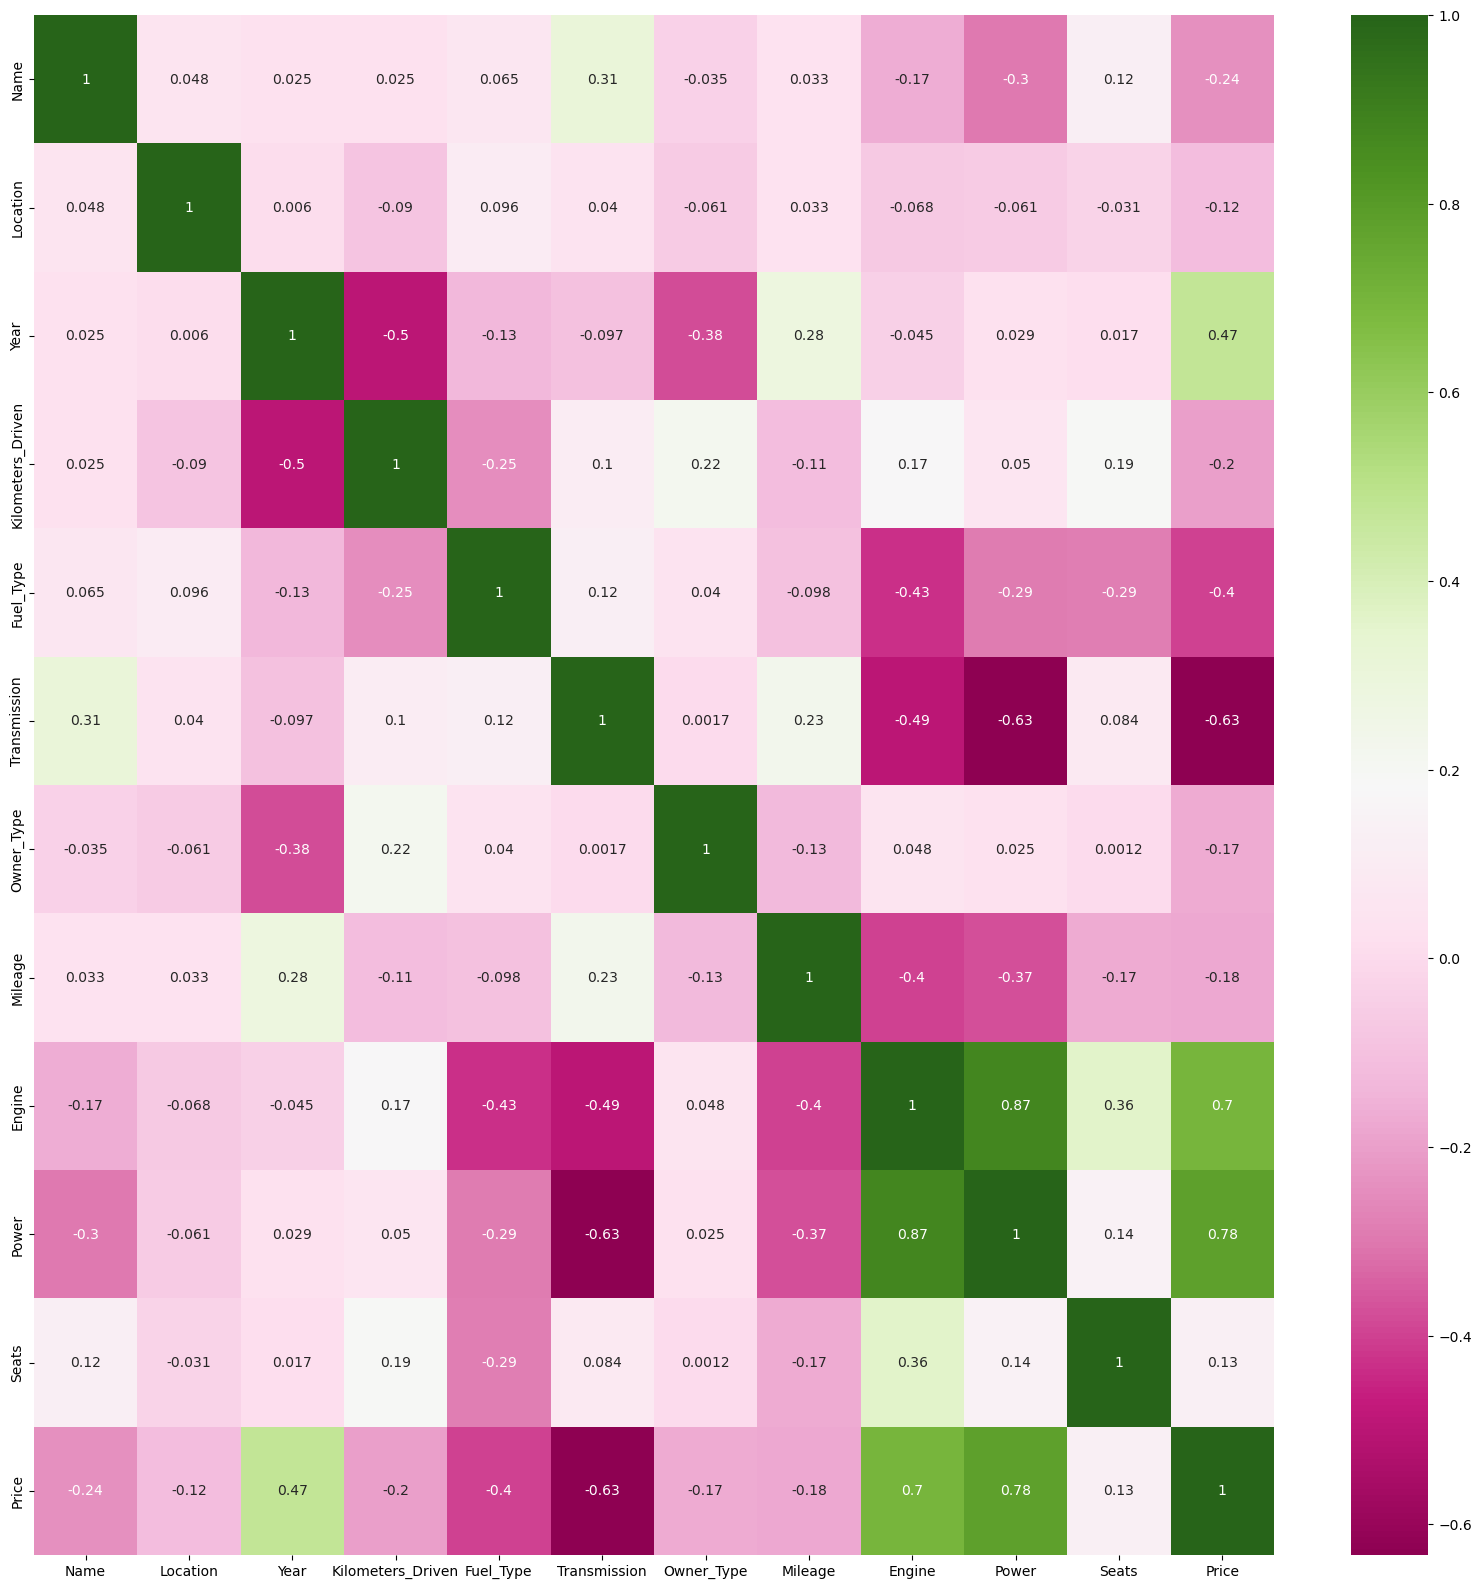

In [71]:
plt.figure(figsize=(20, 20))
cor = df_scaled.corr()
sns.heatmap(cor, cmap= "PiYG", annot=True)
plt.show()

In [72]:
def correlation(dataset, threshold):
  col_corr = set()
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if (corr_matrix.iloc[i, j]) > threshold:
          colname = corr_matrix.columns[i]
          col_corr.add(colname)
  return col_corr

In [73]:
var_to_remove = (correlation(df_scaled, 0.75))

In [74]:
var_to_remove.remove("Price")

In [75]:
var_to_remove

{'Power'}

In [76]:
# df_new = df_scaled.drop("Power", axis=1)

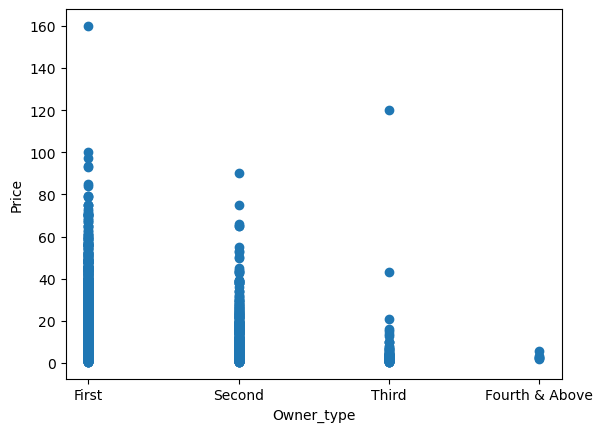

In [77]:
plt.scatter(df_rm["Owner_Type"], df_rm["Price"])
plt.xlabel("Owner_type")
plt.ylabel("Price")
plt.show()

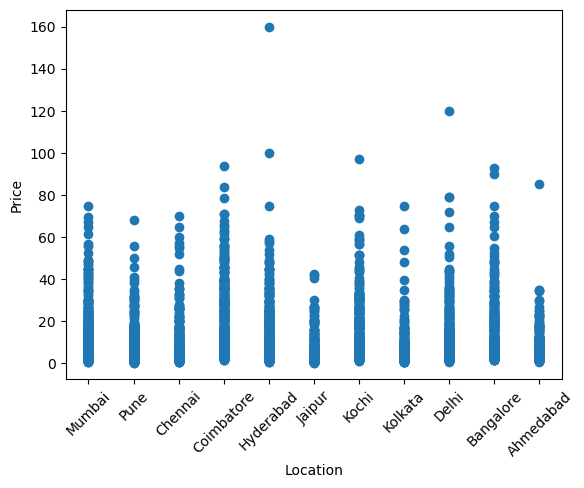

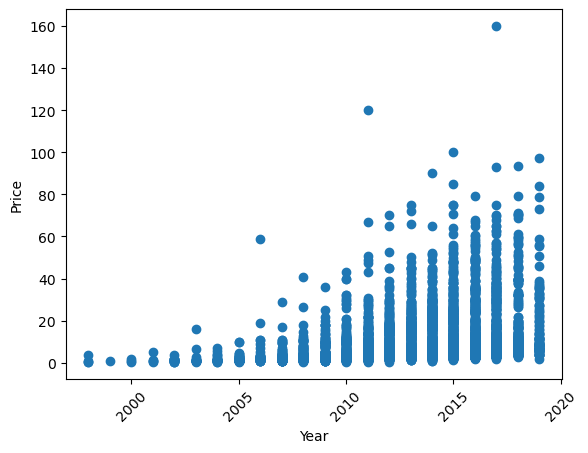

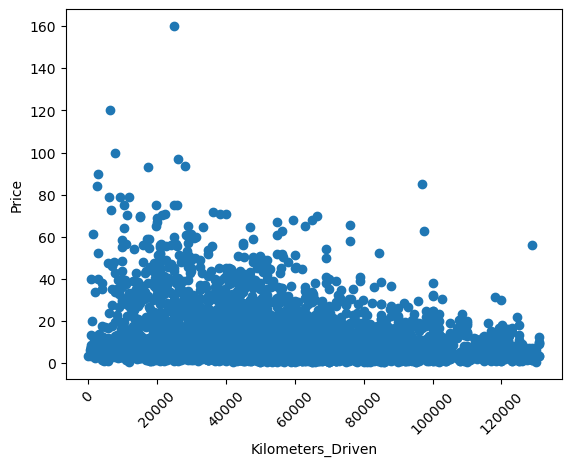

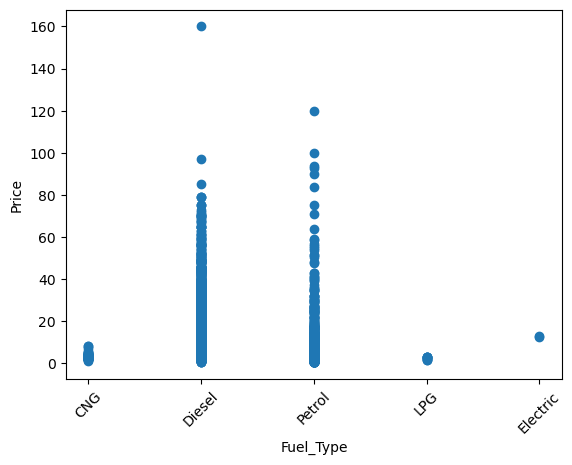

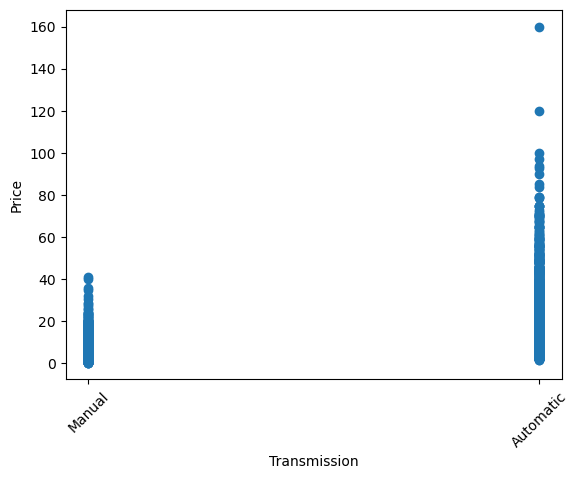

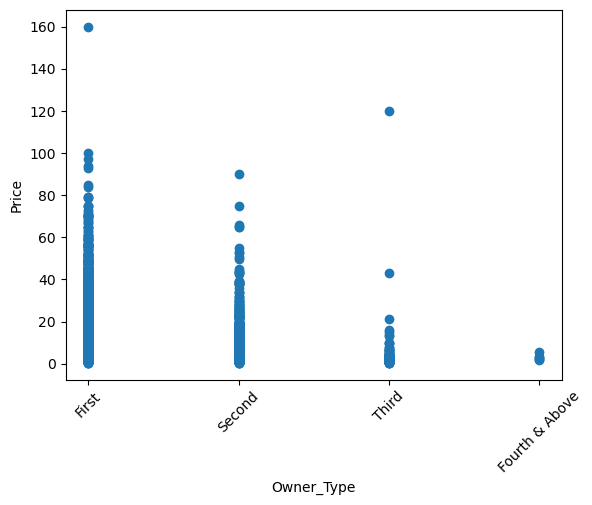

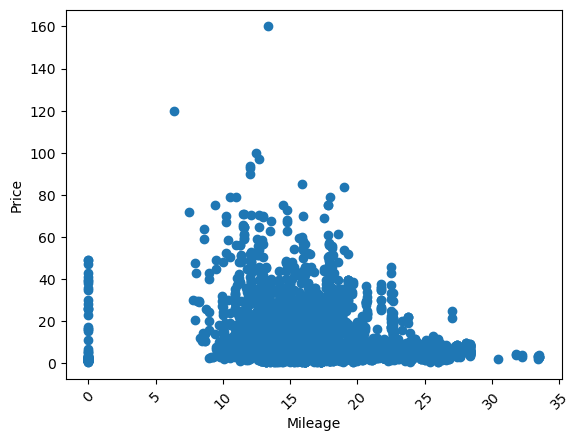

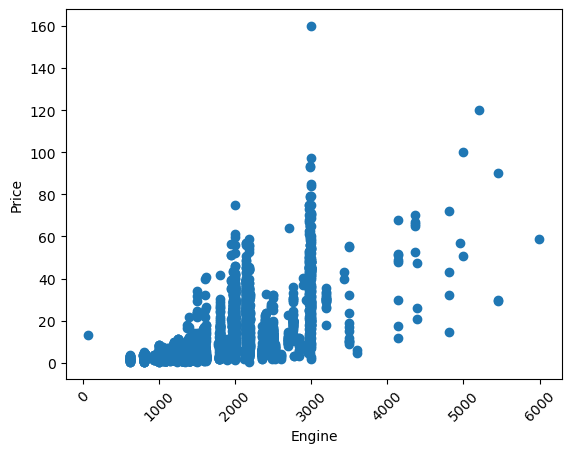

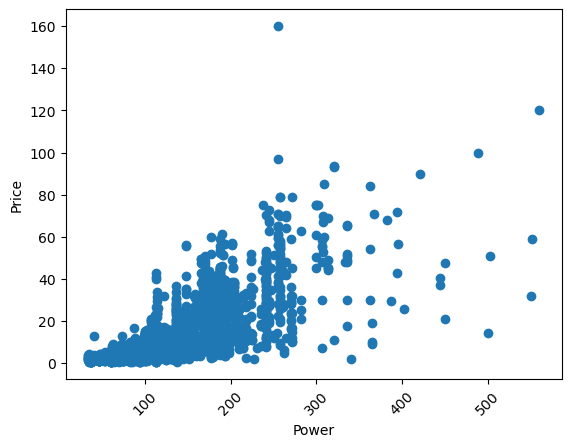

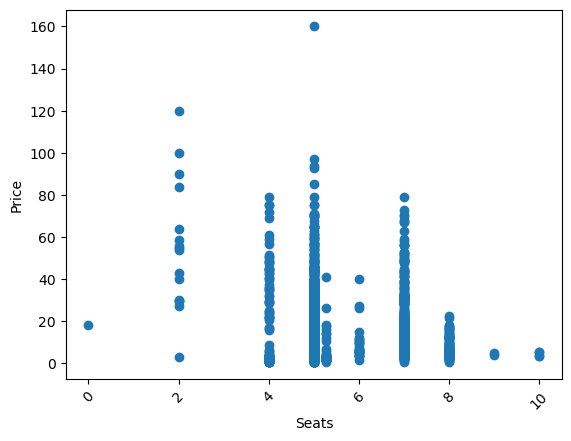

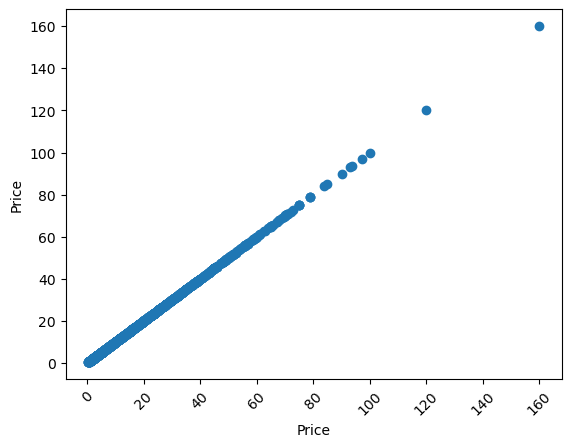

In [78]:
for i in df.columns.drop("Name"):
  plt.scatter(df_rm[i], df_rm["Price"])
  plt.xlabel(f"{i}")
  plt.ylabel("Price")
  plt.xticks(rotation=45)
  plt.show()

In [79]:
from pandas.plotting import scatter_matrix

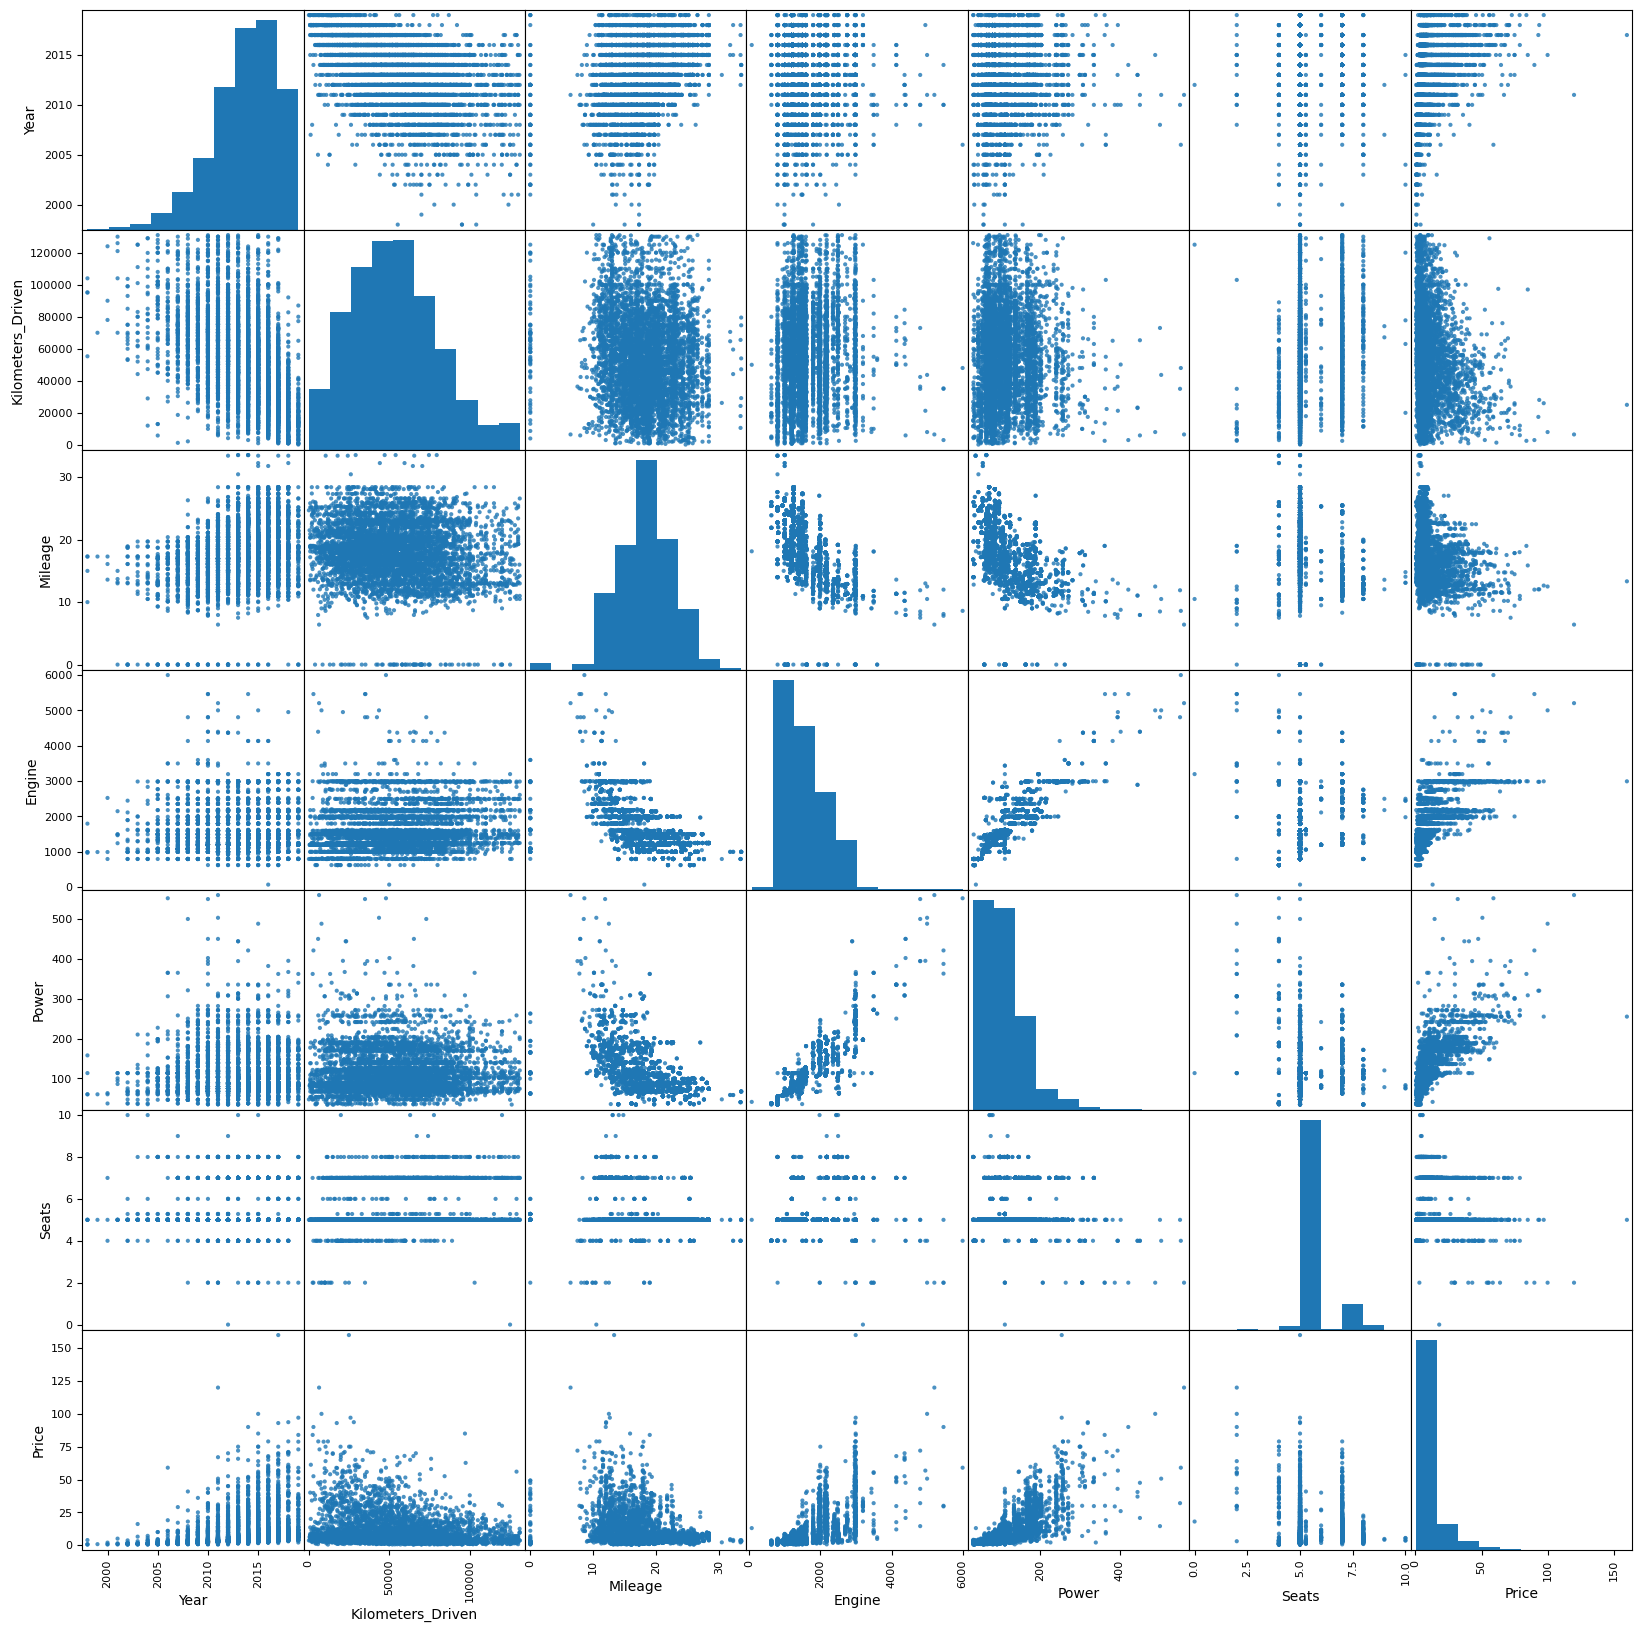

In [80]:
scatter_matrix(df_rm, figsize=(20, 20), alpha = 0.8, diagonal="hist")  # diagonal -- kde for density distribution
plt.show()

In [81]:
import plotly.express as px

In [82]:
fig = px.pie(df_rm, names="Owner_Type", title="Pie Chart for Owner Type" )
fig.show()

In [83]:
df_rm["Name"].nunique()

1834

In [84]:
cat_cols

['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

In [85]:
pie_cols = cat_cols.copy()
pie_cols.remove("Name")

In [86]:
pie_cols

['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

In [87]:
for i in pie_cols:
  fig = px.pie(df_rm, names=i, title=f"Pie Chart for {i}", hole=0.3)
  fig.show()

In [88]:
num_cols  = [x for x in df_rm.columns if df_rm[x].dtype != "object"]

In [89]:
num_cols

['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']

In [90]:
fig = px.scatter(df_rm, x="Kilometers_Driven", y="Price", title="KD vs Price", labels={"Kilometers_Driven": "Kilometers Driven", "Price": "Price"}, color = "Price")
fig.show()

In [91]:
for i in num_cols:
  fig = px.scatter(df_rm, x=i, y="Price", title=f"{i} vs Price", labels={i: i, "Price": "Price"}, color = "Price")
  fig.show()

In [92]:
import seaborn as sns

In [93]:
import matplotlib.pyplot as plt

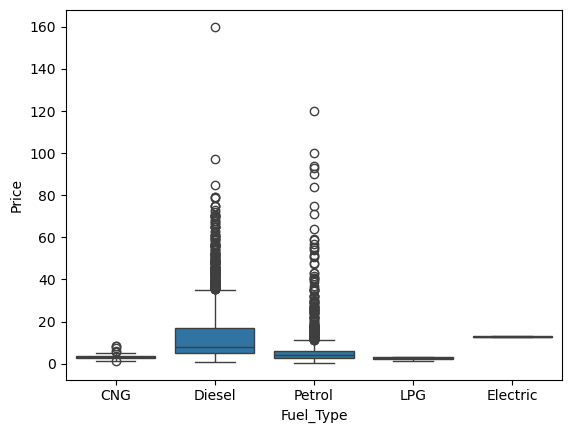

In [94]:
sns.boxplot(x="Fuel_Type", y="Price", data=df_rm)
plt.show()

In [95]:
cat_cols.remove("Name")

In [96]:
cat_cols

['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

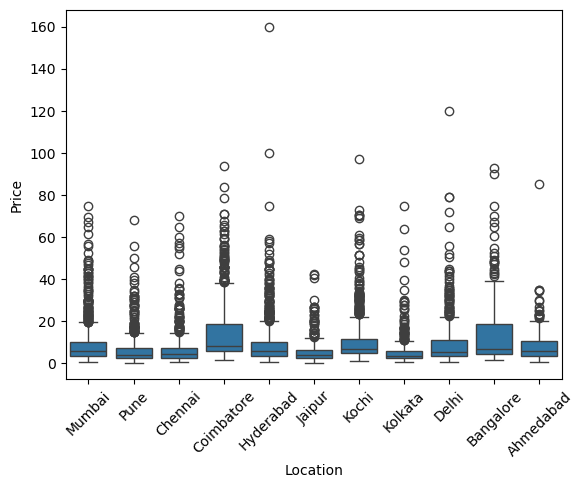

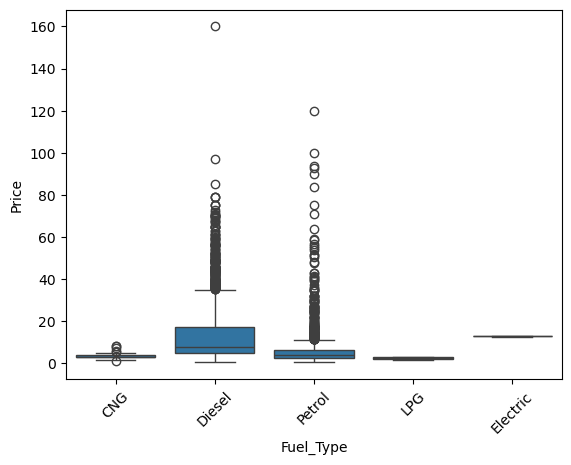

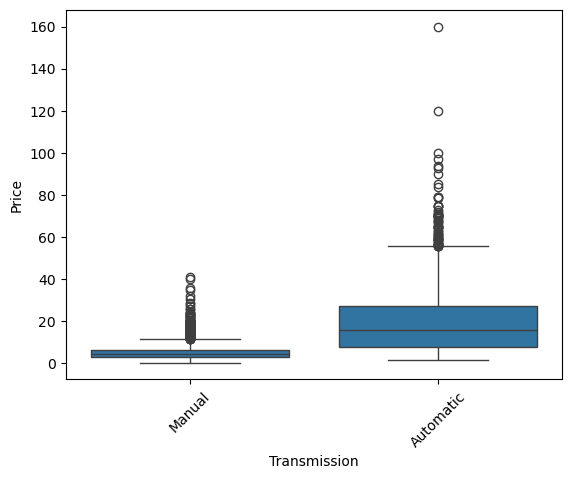

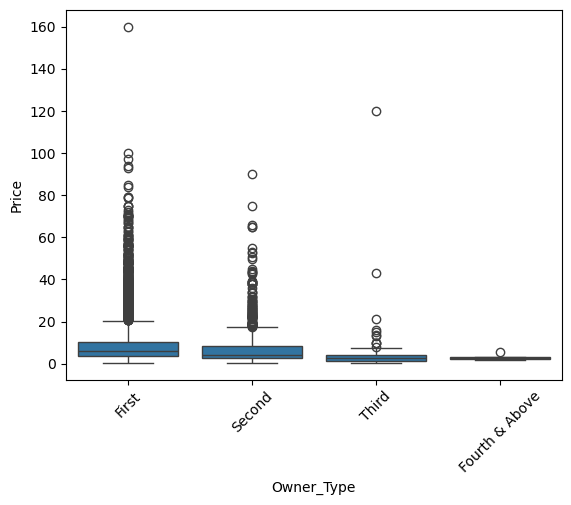

In [97]:
for i in cat_cols:
  sns.boxplot(x=i, y="Price", data=df_rm)
  plt.xticks(rotation=45)
  plt.show()

In [98]:
cat_cols

['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

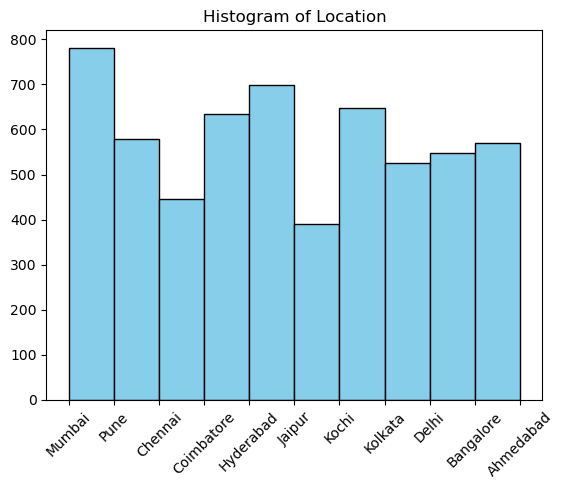

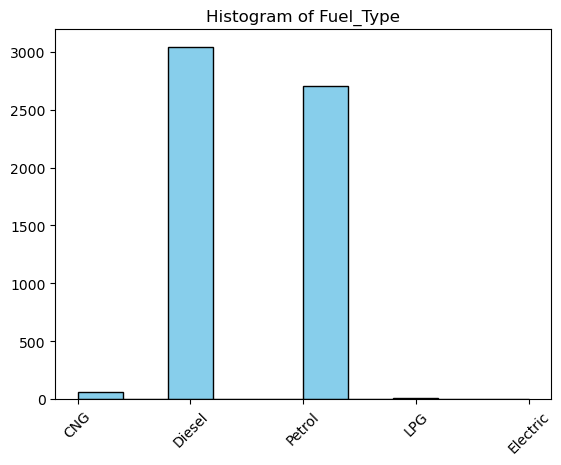

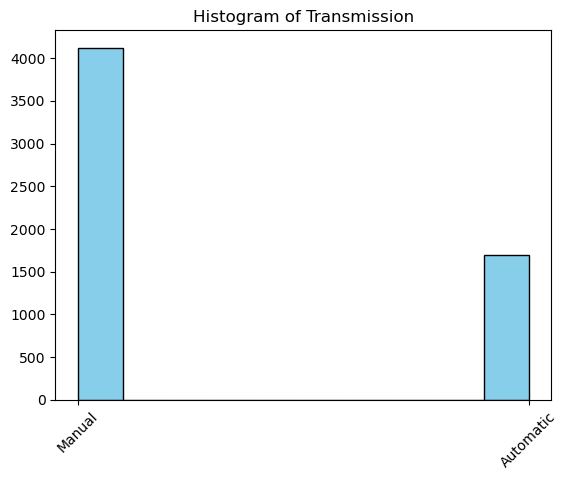

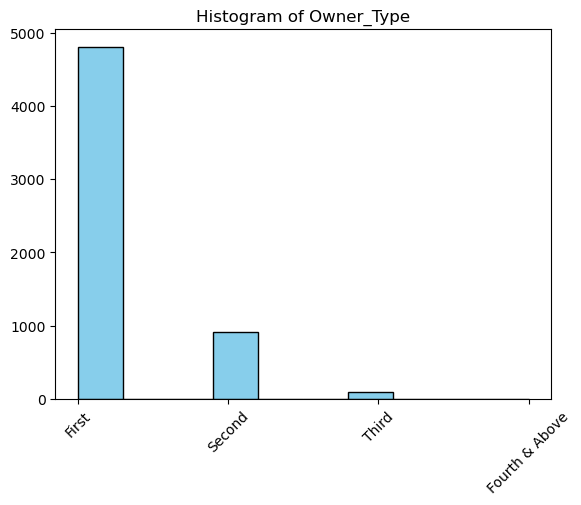

In [99]:
for i in cat_cols:
  plt.hist(df_rm[i], color="skyblue", edgecolor="Black")
  plt.title(f"Histogram of {i}")
  plt.xticks(rotation=45)
  plt.show()

In [100]:
num_cols = [x for x in df_rm if df_rm[x].dtype != "object"]

In [101]:
num_cols

['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']

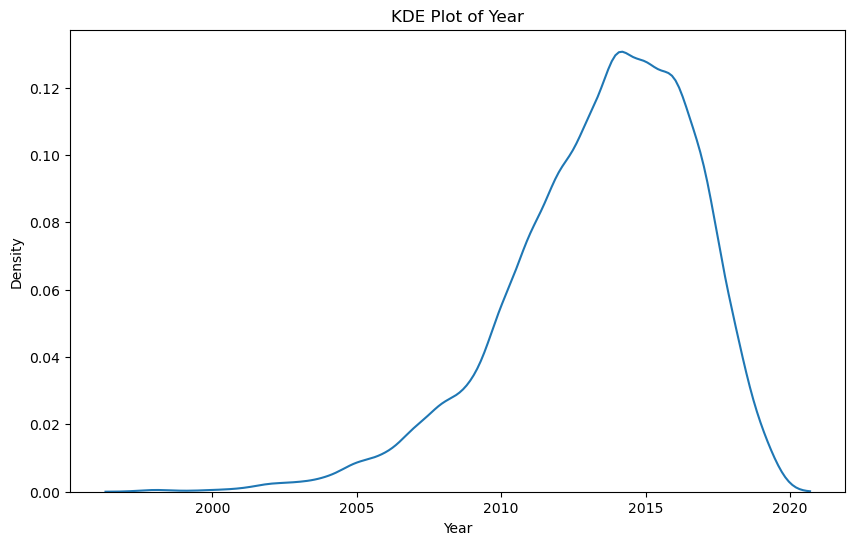

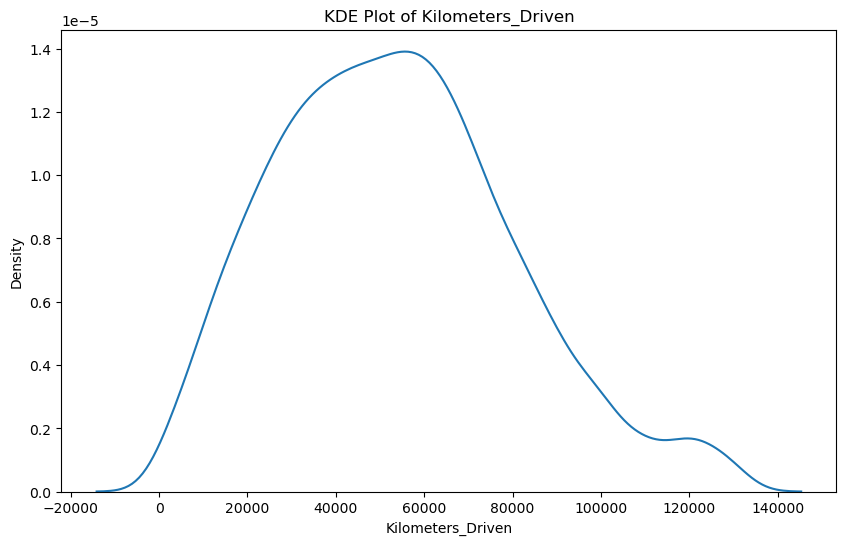

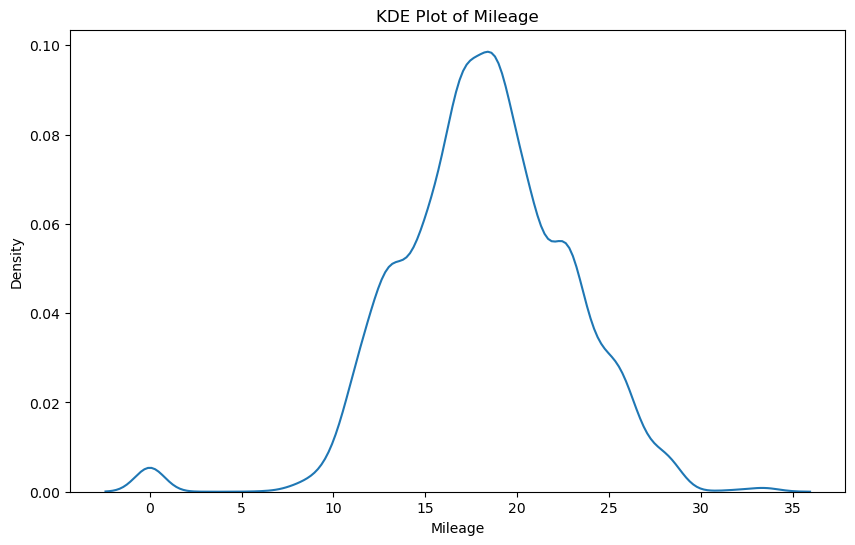

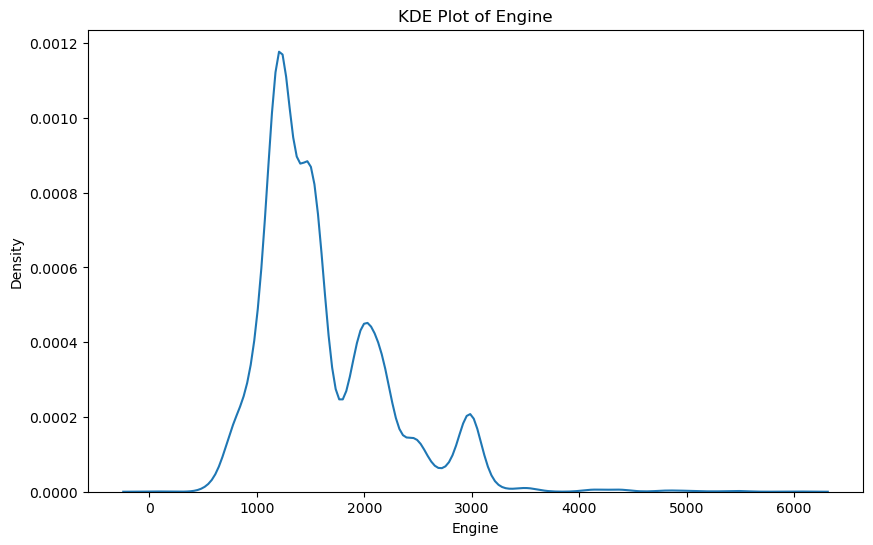

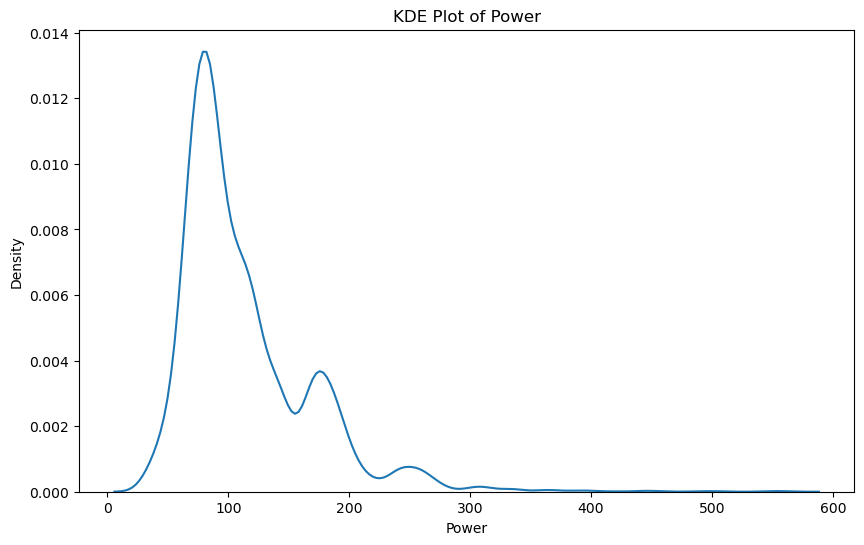

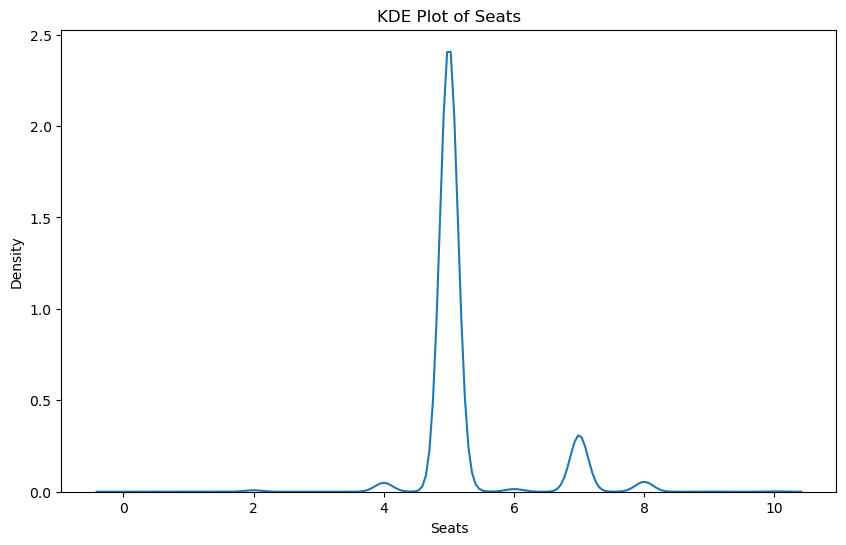

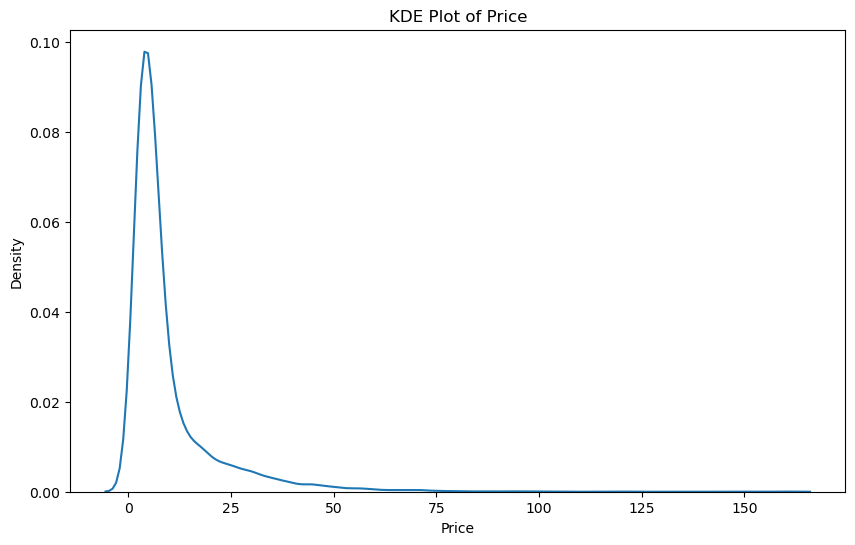

In [102]:
for i in num_cols:
  plt.figure(figsize=(10, 6))
  sns.kdeplot(data=df_rm[i])
  plt.title(f"KDE Plot of {i}")
  plt.xlabel(f"{i}")
  plt.show()

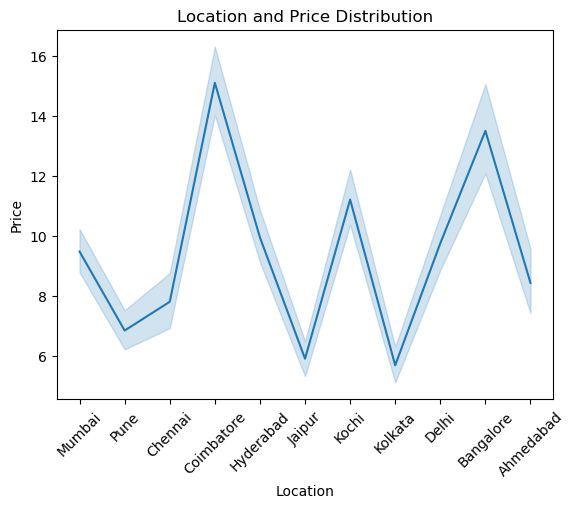

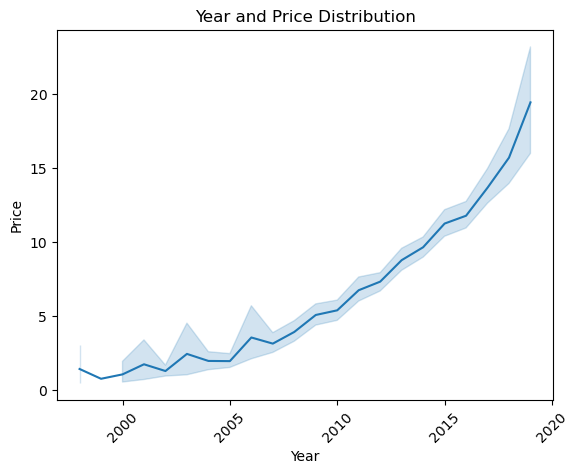

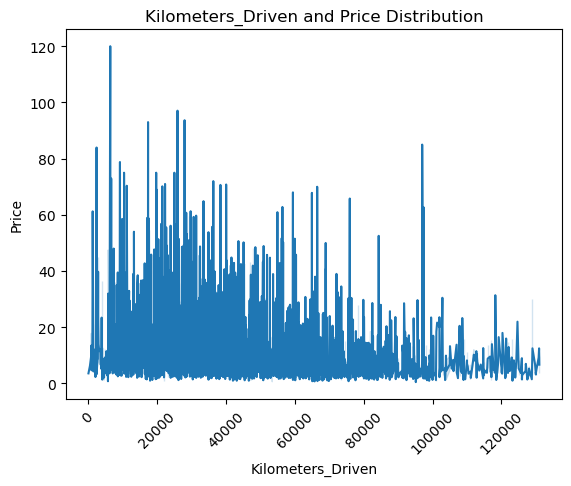

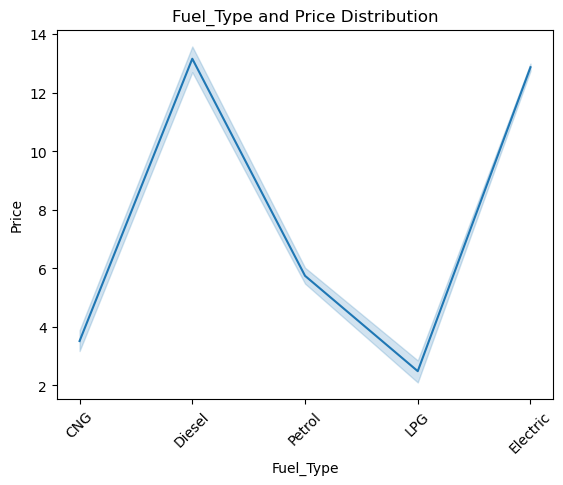

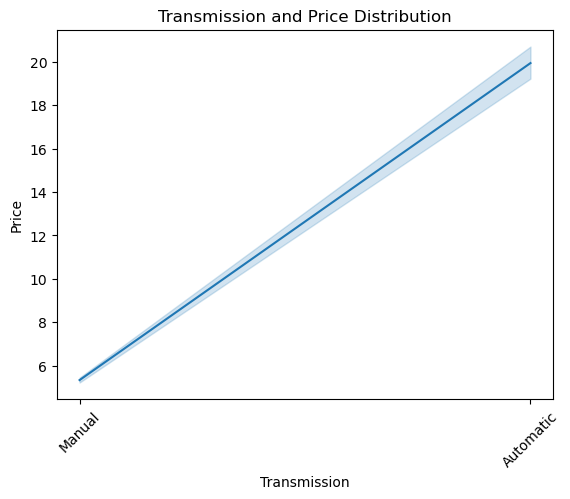

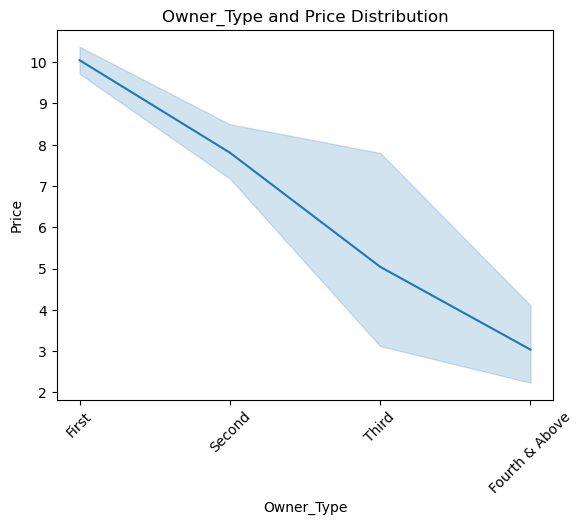

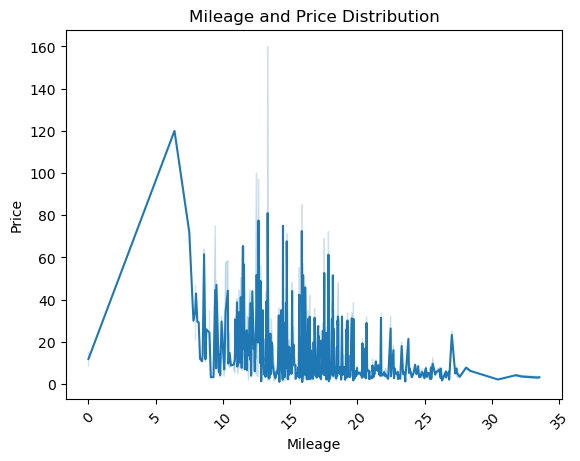

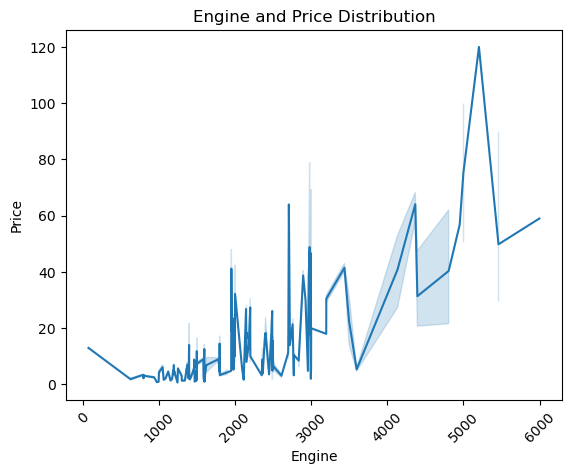

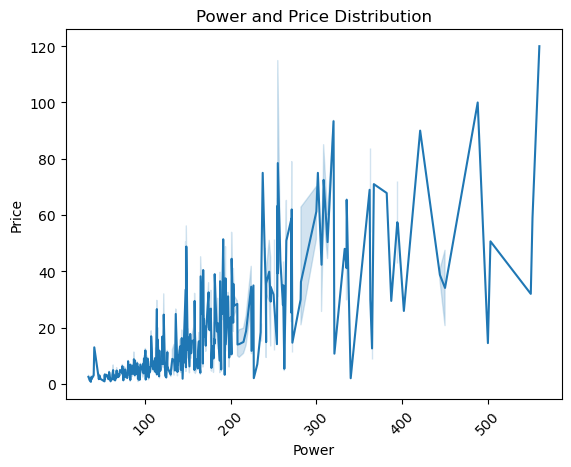

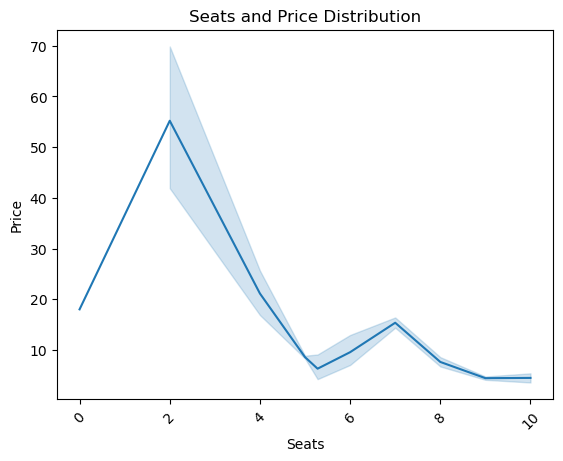

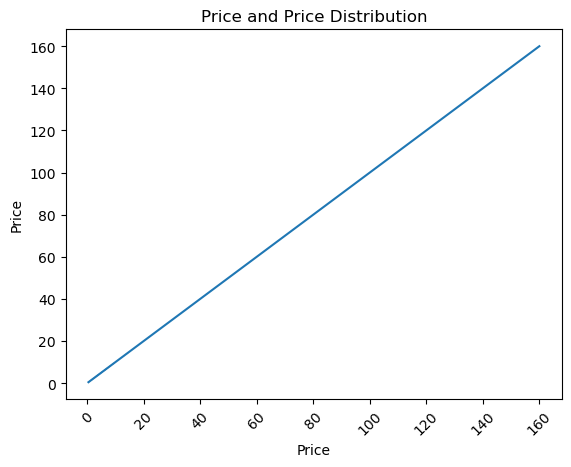

In [103]:
for i in df_rm.columns.drop('Name'):
  sns.lineplot(data=df_rm, x=i, y="Price")
  plt.title(f"{i} and Price Distribution")
  plt.xticks(rotation=45)
  plt.show()

# Excel Questions Solved

1. What is the average selling price of used cars by brand?

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [123]:
df_g = pd.read_csv("used_cars.csv")

In [124]:
df_g

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,7.88 Lakh,4.75
6015,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,NaN,4.00
6016,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,NaN,2.90
6017,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,NaN,2.65


In [125]:
df_g.iloc[0,1].split()[0]

'Maruti'

In [126]:
df_g["Name"]

0                 Maruti Wagon R LXI CNG
1       Hyundai Creta 1.6 CRDi SX Option
2                           Honda Jazz V
3                      Maruti Ertiga VDI
4        Audi A4 New 2.0 TDI Multitronic
                      ...               
6014                    Maruti Swift VDI
6015            Hyundai Xcent 1.1 CRDi S
6016               Mahindra Xylo D4 BSIV
6017                  Maruti Wagon R VXI
6018               Chevrolet Beat Diesel
Name: Name, Length: 6019, dtype: object

In [127]:
df_g["Brand"] = df_g["Name"].apply(lambda x: x.split()[0])

In [128]:
df_g

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,7.88 Lakh,4.75,Maruti
6015,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,NaN,4.00,Hyundai
6016,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,NaN,2.90,Mahindra
6017,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,NaN,2.65,Maruti


In [ ]:
# df_g.groupby("Brand").agg({"Price" : ["mean", "min", "max"]}).reset_index()

In [129]:
df_g.groupby("Brand").agg({"Price" : ["mean"]}).reset_index()

,Brand,Price
,,mean
0,Ambassador,1.350000
1,Audi,25.537712
2,BMW,25.243146
3,Bentley,59.000000
4,Chevrolet,3.044463
5,Datsun,3.049231
6,Fiat,3.269286
7,Force,9.333333
8,Ford,6.889400


2. How many cars are available per year?

In [130]:
q2 = df_g["Year"].value_counts().reset_index()

In [131]:
q2

,Year,count
0,2014,797
1,2015,744
2,2016,741
3,2013,649
4,2017,587
5,2012,580
6,2011,466
7,2010,342
8,2018,298
9,2009,198


In [132]:
import seaborn as sns

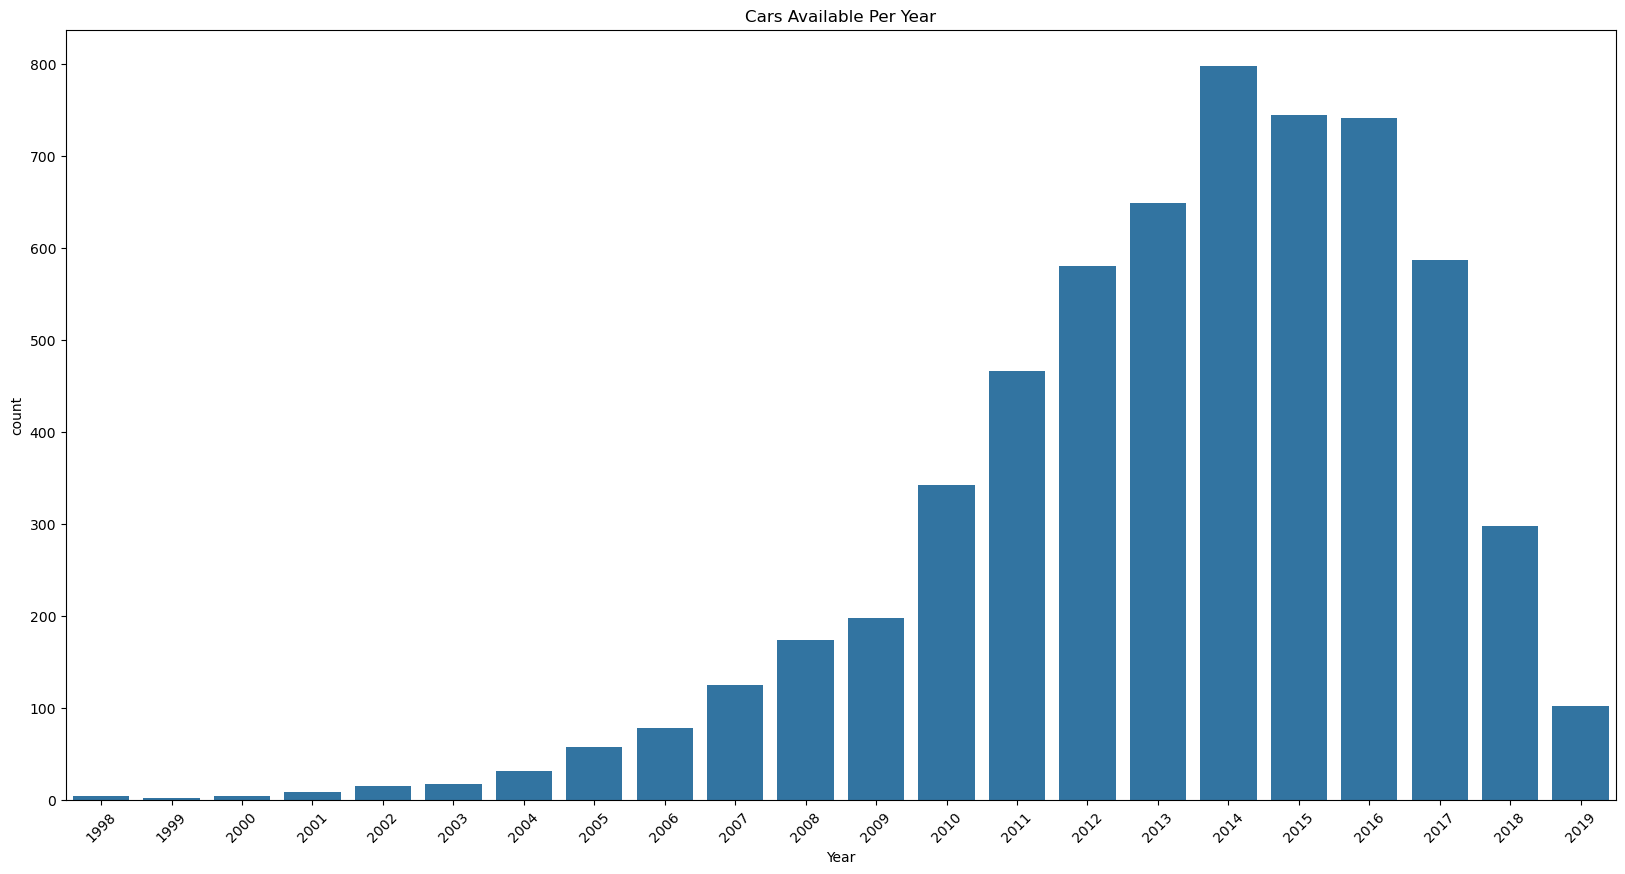

In [133]:
plt.figure(figsize=(20, 10))
sns.barplot(data=q2, x="Year", y="count")
plt.title("Cars Available Per Year")
plt.xticks(rotation=45)
plt.show()

3. What is the average mileage (kmpl/km/kg) by fuel type?

In [134]:
df_g

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,7.88 Lakh,4.75,Maruti
6015,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,NaN,4.00,Hyundai
6016,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,NaN,2.90,Mahindra
6017,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,NaN,2.65,Maruti


In [135]:
def clean_mileage(mileage):
  return float(str(mileage).split()[0]) if pd.notna(mileage) else None

def clean_engine(engine):
  return float(str(engine).split()[0]) if pd.notna(engine) else None

def clean_power(power):
  return float(str(power).split()[0]) if pd.notna(power) and power!= "null bhp" else None

In [136]:
df_g["Mileage"] = df_g["Mileage"].apply(clean_mileage)

In [137]:
df_g

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248 CC,74 bhp,5.0,7.88 Lakh,4.75,Maruti
6015,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120 CC,71 bhp,5.0,NaN,4.00,Hyundai
6016,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498 CC,112 bhp,8.0,NaN,2.90,Mahindra
6017,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.90,998 CC,67.1 bhp,5.0,NaN,2.65,Maruti


In [138]:
q3 = df_g.groupby("Fuel_Type").agg({"Mileage" : "mean"}).reset_index()

In [139]:
import plotly.express as px

In [140]:
q3

,Fuel_Type,Mileage
0,CNG,25.418036
1,Diesel,18.620484
2,Electric,NaN
3,LPG,19.385000
4,Petrol,17.415204


In [141]:
fig = px.pie(q3, names="Fuel_Type", values="Mileage")
fig.show()

4. What is the distribution of cars by transmission type?

In [142]:
# df_g.groupby("Transmission").agg({"Location" : "count"})

In [143]:
q4 = df_g["Transmission"].value_counts().reset_index()

In [144]:
fig = px.pie(q4, names = 'Transmission',values="count", title = 'Pie Chart')
fig.show()

5. Which Owner type offers the most cars, and what's the average selling price?

In [145]:
q5 = df_g.groupby("Owner_Type").agg({"Name":"count", "Price":"mean"}).reset_index()

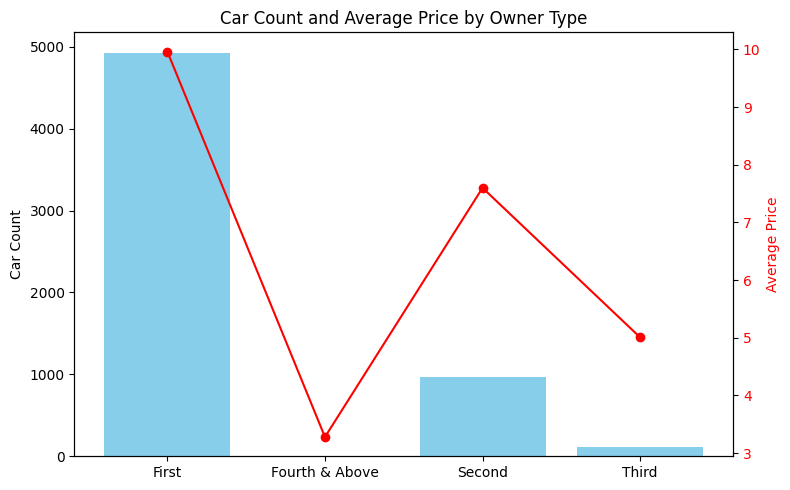

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(q5["Owner_Type"], q5["Name"], color='skyblue', label="Car Count")
ax1.set_ylabel("Car Count", color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(q5["Owner_Type"], q5["Price"], color='red', marker='o', label="Avg Price")
ax2.set_ylabel("Average Price", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Car Count and Average Price by Owner Type")
plt.tight_layout()
plt.show()

6. Which year has the highest average selling price?

In [146]:
year_price = df_g.groupby("Year").agg({"Price" : "mean"}).reset_index()

In [147]:
(year_price.sort_values(by="Price", ascending=False)).iloc[0, ]

Year     2019.000000
Price      19.464118
Name: 21, dtype: float64

7. What is the relationship between engine size (binned) and price?

In [ ]:
df_g["Engine"] = df_g["Engine"].apply(clean_engine)

In [ ]:
df_g

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16 bhp,5.0,NaN,1.75,Maruti
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.2 bhp,5.0,NaN,12.50,Hyundai
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.7 bhp,5.0,8.61 Lakh,4.50,Honda
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76 bhp,7.0,NaN,6.00,Maruti
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.8 bhp,5.0,NaN,17.74,Audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74 bhp,5.0,7.88 Lakh,4.75,Maruti
6015,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71 bhp,5.0,NaN,4.00,Hyundai
6016,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112 bhp,8.0,NaN,2.90,Mahindra
6017,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.1 bhp,5.0,NaN,2.65,Maruti


In [ ]:
df_g["engine_size_bin"] = pd.cut(df_g["Engine"], bins=[0, 1000, 2000, 3000, 4000, 5000, 6000])

In [ ]:
df_g

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand,engine_size_bin
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16 bhp,5.0,NaN,1.75,Maruti,"(0, 1000]"
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.2 bhp,5.0,NaN,12.50,Hyundai,"(1000, 2000]"
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,"(1000, 2000]"
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76 bhp,7.0,NaN,6.00,Maruti,"(1000, 2000]"
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.8 bhp,5.0,NaN,17.74,Audi,"(1000, 2000]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.40,1248.0,74 bhp,5.0,7.88 Lakh,4.75,Maruti,"(1000, 2000]"
6015,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.40,1120.0,71 bhp,5.0,NaN,4.00,Hyundai,"(1000, 2000]"
6016,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.00,2498.0,112 bhp,8.0,NaN,2.90,Mahindra,"(2000, 3000]"
6017,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.90,998.0,67.1 bhp,5.0,NaN,2.65,Maruti,"(0, 1000]"


In [ ]:
q7 = df_g.groupby("engine_size_bin").agg({"Price" : "mean"}).reset_index()

<ipython-input-54-909db014aea4>:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
q7["engine_size_bin"] = q7["engine_size_bin"].astype(str)

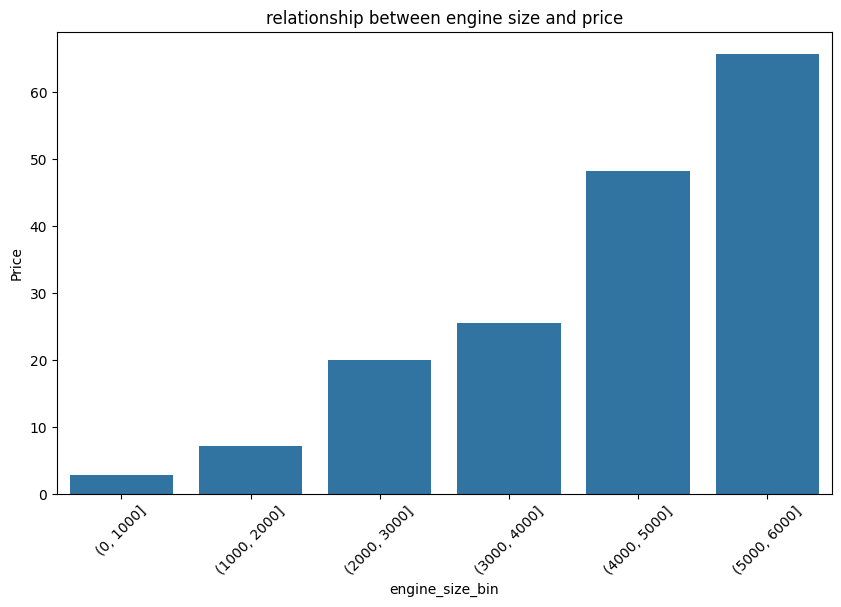

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=q7, x="engine_size_bin", y="Price")
plt.title("relationship between engine size and price")
plt.xticks(rotation=45)
plt.show()